### Step 1: Import Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

In [86]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [4]:
df = pd.read_csv('./data/new.csv')

In [5]:
df.shape

(2240, 29)

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

### Step 3: Preparing Data

In [11]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.shape

(2216, 29)

In [14]:
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [25]:
parts = df['Dt_Customer'].str.split('-', n=3, expand=True)

In [27]:
df['day'] = parts[0].astype('int')
df['month'] = parts[1].astype('int')
df['year'] = parts[2].astype('int')

In [28]:
df.drop(columns=['Z_CostContact', 'Z_Revenue', 'Dt_Customer'], inplace=True)

### Step 4: Data Visulization and Analysis

In [42]:
type_dict = defaultdict(list)
for col in df.columns:
    type_dict[str(df[col].dtype)].append(col)

In [46]:
type_dict['object']

['Education', 'Marital_Status']

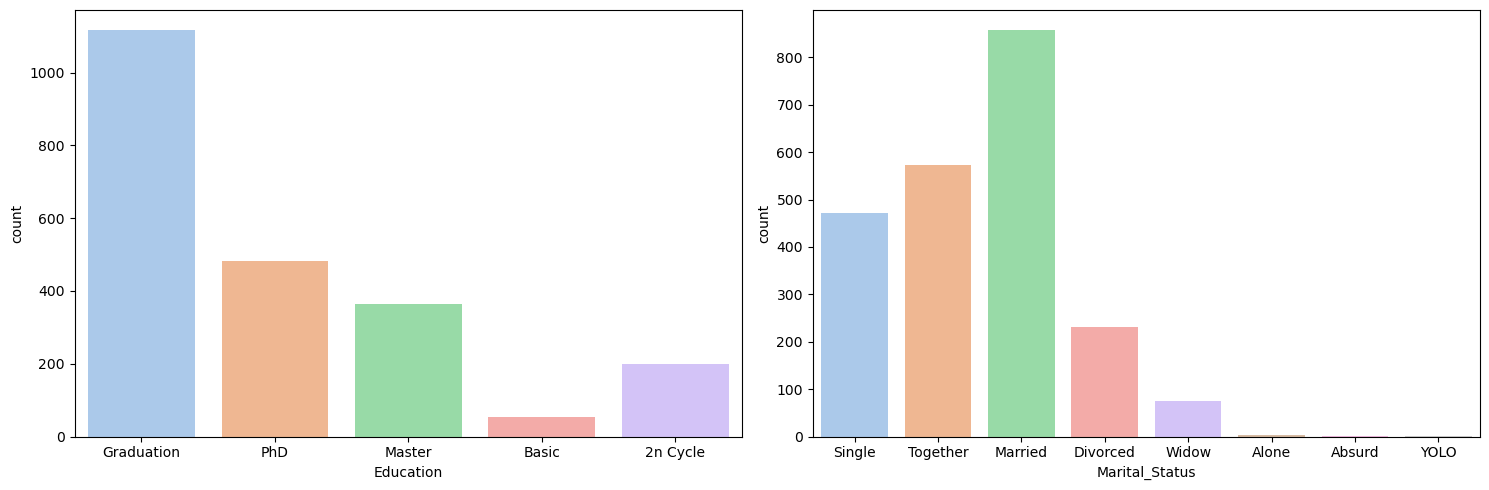

In [65]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(type_dict['object']):
    plt.subplot(1, 2, i + 1)
    sns.countplot(x=df[col], palette='pastel')
plt.tight_layout()

In [62]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

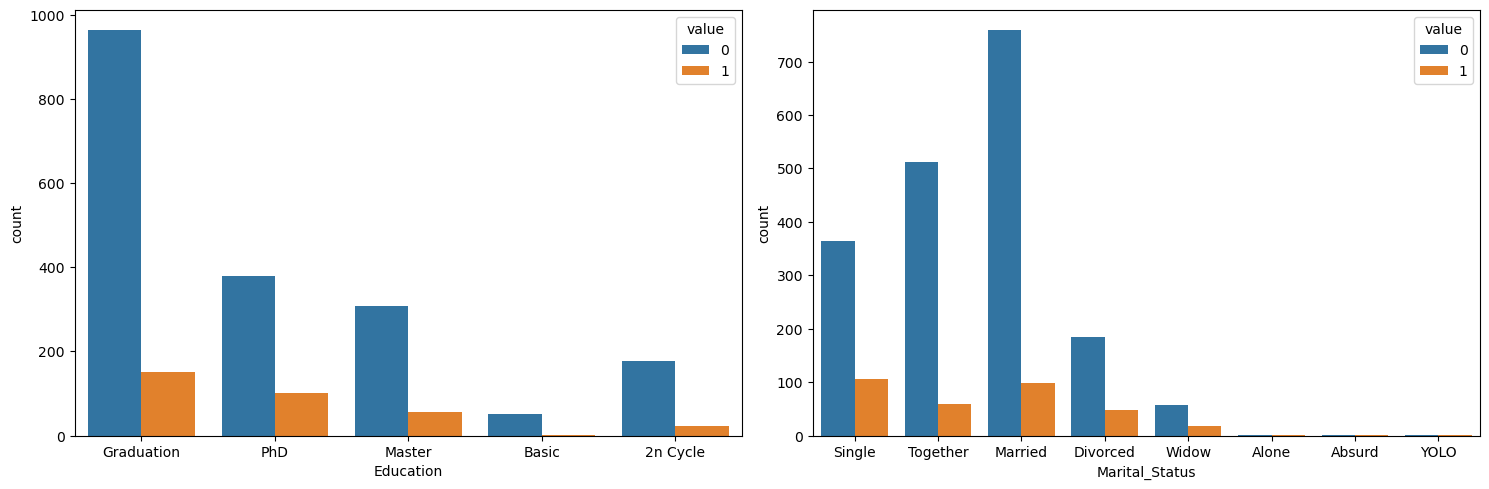

In [69]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(type_dict['object']):
    plt.subplot(1, 2, i + 1)
    df_melted = df.melt(
        id_vars=[col],
        value_vars=['Response'],
        var_name='hue'
    )
    sns.countplot(x=col, hue='value', data=df_melted)
plt.tight_layout()

In [70]:
for col in type_dict['object']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

<Axes: >

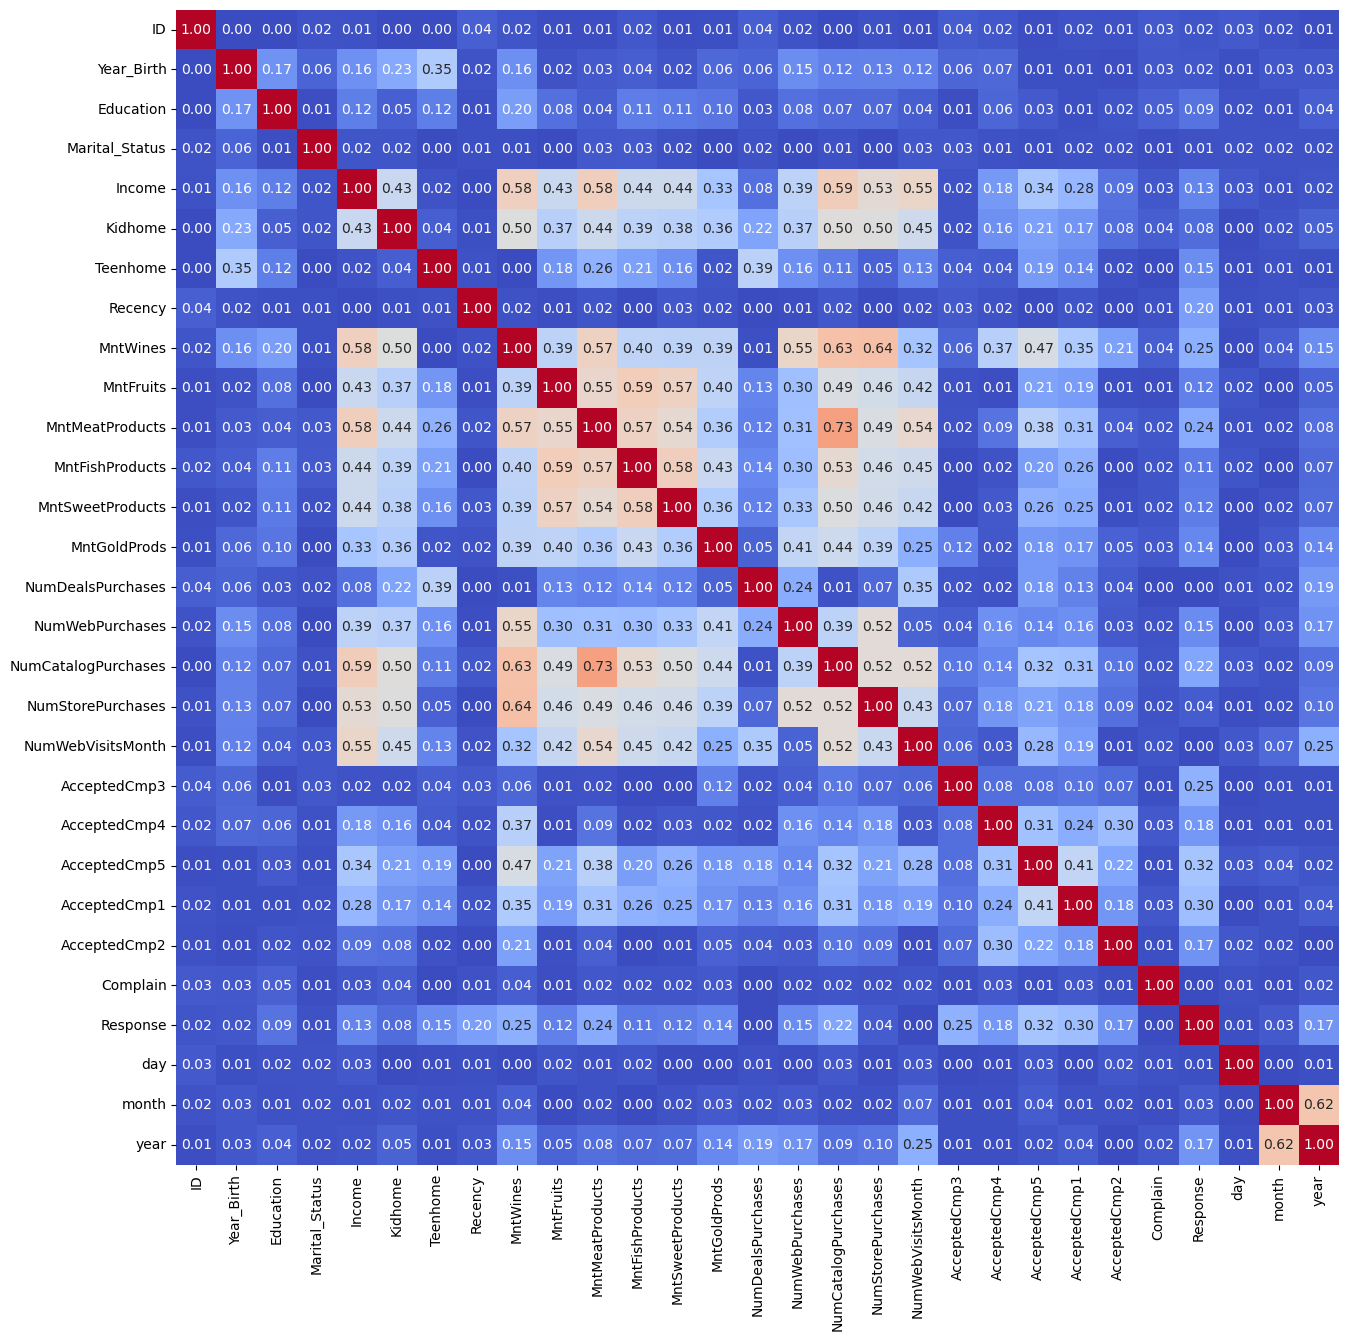

In [77]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr().abs(), annot=True, fmt='.2f', cbar=False, cmap=plt.cm.coolwarm)

In [78]:
scaler = StandardScaler()

In [81]:
data = scaler.fit_transform(df)

### Step 5: Segmentation

In [142]:
model = TSNE(n_components=2, random_state=0)

In [144]:
tsne_data = model.fit_transform(data)

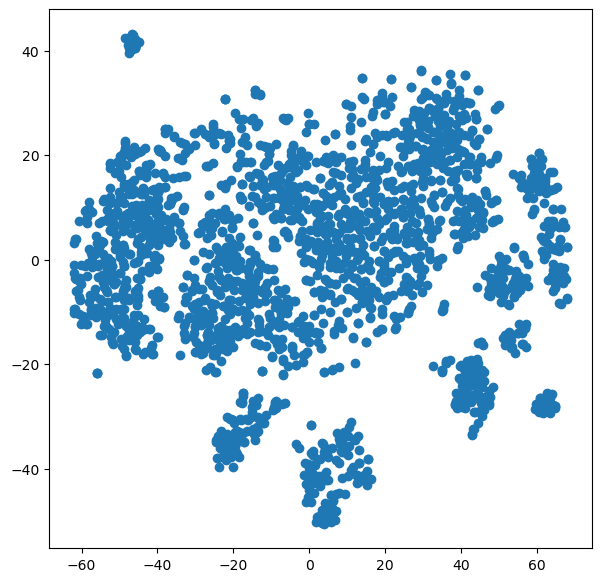

In [145]:
plt.figure(figsize=(7, 7))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1])

In [152]:
error = list()
for n_clusters in range(1, 21):
    model = KMeans(
        n_clusters=n_clusters,
        max_iter=500,
        random_state=22
    )
    model.fit(data)
    error.append(model.inertia_)

<Axes: >

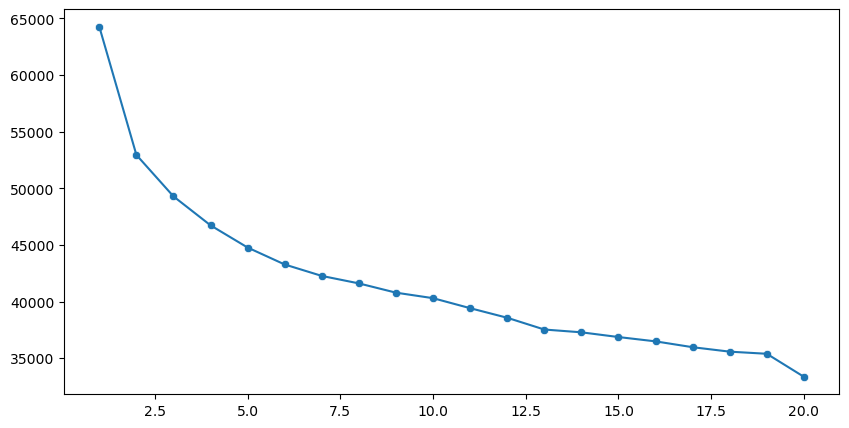

In [153]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 21), y=error)
sns.scatterplot(x=range(1, 21), y=error)

In [178]:
model = KMeans(n_clusters=5, max_iter=500, random_state=22)

In [179]:
segments = model.fit_predict(data)

In [180]:
df_tsne = pd.DataFrame({'x': tsne_data[:, 0], 'y': tsne_data[:, 1], 'segment': segments})

<Axes: xlabel='x', ylabel='y'>

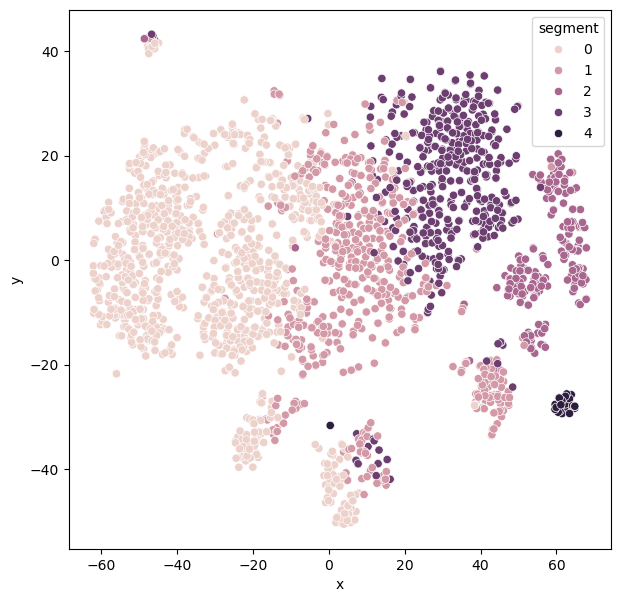

In [181]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x='x', y='y', hue='segment', data=df_tsne)